In [2]:

import pandas as pd
import numpy as np
import seaborn as sns

# to convert list datatypes stored in string formats
import ast

# for nlp tasks - preprocessing
import spacy

# for creating a tf-idf vector 
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load('en_core_web_sm')



#### Data was fetched from the TMDB API with only the required columns, as the specific movie metadata needed to align with the MovieLens dataset was not available in any ready-made dataset available online.

In [8]:
df = pd.read_csv('../data/processed/MovieLense-TMDB-combined-data.csv')

In [9]:

ratings = pd.read_csv(
    "../data/raw/MovieLens 1M/ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names = ['UserID','MovieID','Rating','Timestamp']
)

In [10]:
df.iloc[:,1:].columns

Index(['MovieID', 'Title', 'Genres', 'release_year', 'imdbId', 'tmdbId',
       'title', 'overview', 'original_language', 'genres',
       'production_companies', 'keywords', 'cast', 'crew', 'poster_url'],
      dtype='str')

**Verifying shape, nulls, and data types before building the content-based pipeline.**

In [11]:
print(df.shape)


(3697, 16)


In [12]:
print(df.isnull().sum())


Unnamed: 0              0
MovieID                 0
Title                   0
Genres                  0
release_year            0
imdbId                  0
tmdbId                  0
title                   0
overview                0
original_language       0
genres                  0
production_companies    0
keywords                0
cast                    0
crew                    0
poster_url              0
dtype: int64


In [13]:
print(df.dtypes)

Unnamed: 0              int64
MovieID                 int64
Title                     str
Genres                    str
release_year            int64
imdbId                  int64
tmdbId                  int64
title                     str
overview                  str
original_language         str
genres                    str
production_companies      str
keywords                  str
cast                      str
crew                      str
poster_url                str
dtype: object


In [14]:
print(df.iloc[0][['genres', 'cast', 'crew', 'keywords']])

genres         ['Family', 'Comedy', 'Animation', 'Adventure']
cast        ['Tom Hanks', 'Tim Allen', 'Don Rickles', 'Jim...
crew                                        ['John Lasseter']
keywords    ['rescue', 'friendship', 'mission', 'jealousy'...
Name: 0, dtype: object


<Axes: xlabel='original_language', ylabel='count'>

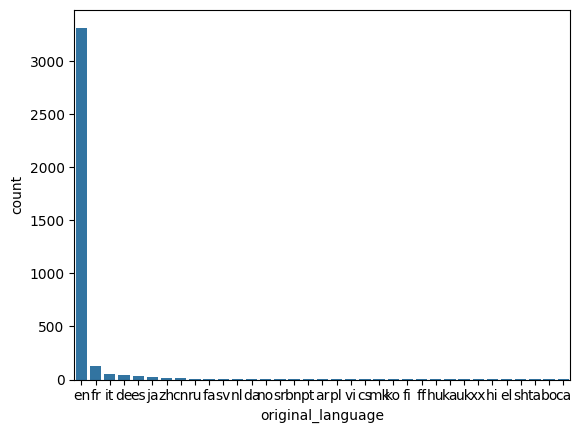

In [15]:
sns.barplot(df['original_language'].value_counts())

most of the movies are English

## Data Wrangling

In [16]:
# mergeing genre columns from both MovieLense and Tmdb


ast.literal_eval(df['genres'][0])


def merge_rows(row):
    movielense_genre    = row['Genres'].split('|')
    tmdb_genre          = ast.literal_eval(row['genres'])
    
    merged              = movielense_genre + tmdb_genre
    merged              = {i.lower() for i in merged}  # making a set, so there are no duplicates
    
    return list(merged)


df['genre'] = df.apply(merge_rows, axis=1)

df = df.drop(columns = ['Genres','genres' ])

In [17]:
df.head(1)

,Unnamed: 0,MovieID,Title,release_year,imdbId,tmdbId,title,overview,original_language,production_companies,keywords,cast,crew,poster_url,genre
0,0,1,Toy Story (1995),1995,114709,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...",en,['Pixar'],"['rescue', 'friendship', 'mission', 'jealousy'...","['Tom Hanks', 'Tim Allen', 'Don Rickles', 'Jim...",['John Lasseter'],https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,"[family, children's, adventure, comedy, animat..."


In [18]:
df = df[['MovieID','imdbId','tmdbId', 'title','release_year', 'original_language', 'genre', 'overview', 'production_companies', 'keywords', 'cast', 'crew', 'poster_url' ]]

In [19]:
df = df.rename(columns={'crew':'director'})

In [20]:
df.head(2)

,MovieID,imdbId,tmdbId,title,release_year,original_language,genre,overview,production_companies,keywords,cast,director,poster_url
0,1,114709,862,Toy Story,1995,en,"[family, children's, adventure, comedy, animat...","Led by Woody, Andy's toys live happily in his ...",['Pixar'],"['rescue', 'friendship', 'mission', 'jealousy'...","['Tom Hanks', 'Tim Allen', 'Don Rickles', 'Jim...",['John Lasseter'],https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...
1,2,113497,8844,Jumanji,1995,en,"[family, fantasy, adventure, children's]",When siblings Judy and Peter discover an encha...,"['TriStar Pictures', 'Interscope Communication...","['giant insect', 'board game', 'disappearance'...","['Robin Williams', 'Kirsten Dunst', 'Bradley P...",['Joe Johnston'],https://image.tmdb.org/t/p/w500/vgpXmVaVyUL7GG...


## Saving this cleaned version separately for later displaying this information in the UI 

In [21]:
# df.to_csv('MovieLense-TMDB-clean-data.csv')

### Preparing for TF-IDF Vectorization

In [22]:
# # removing columns as they are not required in the vector
# # imdbid, tmdbid    - not required
# # release_year      - meaningless in tfidf vector
# # poster_url        - not required

df = df.drop(columns = ['imdbId', 'tmdbId', 
                        'release_year', 
                        'poster_url'
                        ])

In [23]:
df.head()

,MovieID,title,original_language,genre,overview,production_companies,keywords,cast,director
0,1,Toy Story,en,"[family, children's, adventure, comedy, animat...","Led by Woody, Andy's toys live happily in his ...",['Pixar'],"['rescue', 'friendship', 'mission', 'jealousy'...","['Tom Hanks', 'Tim Allen', 'Don Rickles', 'Jim...",['John Lasseter']
1,2,Jumanji,en,"[family, fantasy, adventure, children's]",When siblings Judy and Peter discover an encha...,"['TriStar Pictures', 'Interscope Communication...","['giant insect', 'board game', 'disappearance'...","['Robin Williams', 'Kirsten Dunst', 'Bradley P...",['Joe Johnston']
2,3,Grumpier Old Men,en,"[comedy, romance]",A family wedding reignites the ancient feud be...,"['Lancaster Gate', 'Warner Bros. Pictures']","['fishing', 'sequel', 'old man', 'best friend'...","['Walter Matthau', 'Jack Lemmon', 'Ann-Margret...",['Howard Deutch']
3,4,Waiting to Exhale,en,"[drama, comedy, romance]","Cheated on, mistreated and stepped on, the wom...",['20th Century Fox'],"['based on novel or book', 'single mother', 'd...","['Whitney Houston', 'Angela Bassett', 'Loretta...",['Forest Whitaker']
4,5,Father of the Bride Part II,en,"[family, comedy]",Just when George Banks has recovered from his ...,"['Touchstone Pictures', 'Sandollar Productions']","['daughter', 'baby', 'parent child relationshi...","['Steve Martin', 'Diane Keaton', 'Martin Short...",['Charles Shyer']


### Merging Multi-Word Tokens to Prevent Token Splitting in TF-IDF

This applies to two types of fields:

**Names:** (cast, director, production company) — Names like "Akshay Kumar" 
must be merged into "AkshayKumar", otherwise TF-IDF splits them into two tokens:

| akshay | kumar |
|-------------|-------|
| 1           | 1     |

This causes "akshay" to match every other Akshay in the dataset,
and "kumar" to match every other Kumar — losing the identity of the person entirely.

**Multi-word keywords** (keywords) — Phrases like "board game" must be merged into 
"boardgame", otherwise "board" and "game" match unrelated movies that happen to 
contain those words in their overview.

In both cases, merging ensures a token only matches when the exact same 
entity or concept appears in another movie.(eg: keyword has "boardgame", cast has "AkshayKumar")

### Note:
Named entities (e.g. "Tony Stark", "Wonder Woman") within overviews are not merged,
as the cast, director, and keywords columns already capture identity-level signals.

Named Entity Recognition(NER) based merging would currently be out of scope, as the focus is to build a recommender system. It still is a valid future improvement.




In [24]:
def merge_names(lst):
    
    """This function goes through a list of strings(Names) and removes spaces"""
        
    output = []
    
    # the lists are stored in string formats
    try:
        for name in ast.literal_eval(lst): # converts "[123]" to [123]
            output.append(name.replace(' ',''))
    
    # lists are stored as lists
    except:
        for name in (lst): 
            output.append(name.replace(' ',''))
    
        
    return output

merge_names("['John Nolan', 'Tim Bradford']")

['JohnNolan', 'TimBradford']

In [25]:
df['production_companies'] = df['production_companies'].apply(merge_names)
df['cast'] = df['cast'].apply(merge_names)
df['director'] = df['director'].apply(merge_names)


df['keywords'] = df['keywords'].apply(merge_names)
df['genre'] = df['genre'].apply(merge_names)


In [26]:
df.head(2)

,MovieID,title,original_language,genre,overview,production_companies,keywords,cast,director
0,1,Toy Story,en,"[family, children's, adventure, comedy, animat...","Led by Woody, Andy's toys live happily in his ...",[Pixar],"[rescue, friendship, mission, jealousy, villai...","[TomHanks, TimAllen, DonRickles, JimVarney, Wa...",[JohnLasseter]
1,2,Jumanji,en,"[family, fantasy, adventure, children's]",When siblings Judy and Peter discover an encha...,"[TriStarPictures, InterscopeCommunications, Te...","[giantinsect, boardgame, disappearance, jungle...","[RobinWilliams, KirstenDunst, BradleyPierce, B...",[JoeJohnston]


Adding prefixes to languages so they dont get misinterpreted as other words in tf-idf

hi -> lang_hi   (hindi) 

In [27]:
def add_lang_prefix(text):
    return f"lang_{text}"

add_lang_prefix('hi')

'lang_hi'

In [28]:
df['original_language'] = df['original_language'].apply(add_lang_prefix)

In [29]:
df.head(2)

,MovieID,title,original_language,genre,overview,production_companies,keywords,cast,director
0,1,Toy Story,lang_en,"[family, children's, adventure, comedy, animat...","Led by Woody, Andy's toys live happily in his ...",[Pixar],"[rescue, friendship, mission, jealousy, villai...","[TomHanks, TimAllen, DonRickles, JimVarney, Wa...",[JohnLasseter]
1,2,Jumanji,lang_en,"[family, fantasy, adventure, children's]",When siblings Judy and Peter discover an encha...,"[TriStarPictures, InterscopeCommunications, Te...","[giantinsect, boardgame, disappearance, jungle...","[RobinWilliams, KirstenDunst, BradleyPierce, B...",[JoeJohnston]


Preprocessing text in overview

In [30]:
text = "The striped bats are hanging on their feet for best"

def preprocess_overview(text):

    doc = nlp(text)

    filtered_tokens = [
        token.lemma_.lower()    # lemmatizing a word, and lowercasing it
        for token in doc
        if not token.is_stop    # checks if the word is a stop word
        and not token.is_punct  # check if
        and not token.text.startswith("'")   # removes 's, 're, 've, etc.
        and not token.is_space  # removes spaces
        # and token.is_alpha    # we could have removed numbers, but i think overview may contain "story based in 1999"
    ]
    
    return filtered_tokens

preprocess_overview(text)

['striped', 'bat', 'hang', 'foot', 'good']

In [31]:
df['overview'] = df['overview'].apply(preprocess_overview)

In [32]:
df.head(1)

,MovieID,title,original_language,genre,overview,production_companies,keywords,cast,director
0,1,Toy Story,lang_en,"[family, children's, adventure, comedy, animat...","[lead, woody, andy, toy, live, happily, room, ...",[Pixar],"[rescue, friendship, mission, jealousy, villai...","[TomHanks, TimAllen, DonRickles, JimVarney, Wa...",[JohnLasseter]


converting lists stored in string formats to lists

In [33]:
def convert_to_list(str_lst):
    try:
        return ast.literal_eval(str_lst)
    
    except:
        return str_lst

In [34]:
df['genre'] = df['genre'].apply(convert_to_list)
df['overview'] = df['overview'].apply(convert_to_list)
df['production_companies'] = df['production_companies'].apply(convert_to_list)
df['keywords'] = df['keywords'].apply(convert_to_list)
df['cast'] = df['cast'].apply(convert_to_list)
df['director'] = df['director'].apply(convert_to_list)

converting orginal_language to list like others so we can easliy add all columnss

In [35]:
df['original_language'] = df['original_language'].apply(lambda x : [x])

In [36]:
df.head(1)

,MovieID,title,original_language,genre,overview,production_companies,keywords,cast,director
0,1,Toy Story,[lang_en],"[family, children's, adventure, comedy, animat...","[lead, woody, andy, toy, live, happily, room, ...",[Pixar],"[rescue, friendship, mission, jealousy, villai...","[TomHanks, TimAllen, DonRickles, JimVarney, Wa...",[JohnLasseter]


Combining all processed fields into a single string — commonly referred to as the **"soup"**.

Certain fields are repeated twice to increase their TF-IDF weight, as viewers often 
choose movies based on specific factors regardless of the plot.

For example:
- **Cast & Director** — viewers follow specific actors and directors
- **Genre & Keywords** — viewers seek specific experiences (romance, superhero, thriller)


### Note:

Repeating a field twice increases its **TF (Term Frequency)** within that movie's soup,
but does not affect **IDF (Inverse Document Frequency)**, as IDF is calculated at the 
corpus level — based on how many movies contain a token, not how many times it appears 
within a single movie. Final TF-IDF score = TF × IDF, so doubling TF doubles the weight
for that token in that movie only.

genre       - people might be interested in romance, thriller, etc movies

keywords    - people might be interested in "based on a book on novel" or "superhero" movies (I love superhero content) 

cast        - everyone loves following a specific actor's work. No? #AkshayKummarGang

director    - everyone loves following a specific director's work. No? (wannabe nolan fans?)



In [37]:
df['soup'] = (df['original_language'] + 
              
              df['genre']*2 + 
              
              df['overview'] + df['production_companies'] + 
              
              df['keywords']*2 + 
              
              df['cast']*2 + 
              
              df['director']*2)

df['soup'] = df['soup'].apply(lambda x: ' '.join(x))

In [38]:
df = df.drop(columns = ['original_language','genre','overview','production_companies','keywords','cast','director'] )

Now, that we have the soup string column

We **Finally** make a TF-IDF Vector

In [46]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['soup'])

In [47]:
tfidf_matrix[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 64 stored elements and shape (1, 45119)>

In [48]:
type(tfidf_matrix)

scipy.sparse._csr.csr_matrix

load the matrix

We need a map to convert **MovieId** to **index number** to be able to access it in the **TF-IDF matrix**

In [51]:
cb_movie_to_id = dict(zip(df['MovieID'], df.index))

cb_id_to_movie = {value:key for key,value in cb_movie_to_id.items()}

In [52]:
print(ratings['UserID'].value_counts().head())

print(ratings['UserID'].value_counts().tail())


UserID
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
Name: count, dtype: int64
UserID
5533    20
5725    20
5828    20
5904    20
6038    20
Name: count, dtype: int64


As we can see that **20** minimum number of movies that a user may have rated.

so we can safely take atleast top 20 movies for existing users

In [457]:
df.set_index('MovieID',inplace = True)

In [ ]:
def content_based_recommend(user_id,num_movies = 40):
    
    """
    Recommends movies using Content Based Recommendation.
    Recommends based on user's top rated movies
    Builds a taste vector by averaging TF-IDF vectors of favourite movies.
    Excludes movies the user has already watched(rated in this case).
    """
    
    # Selecting top rated movies by the user
    user_df = ratings[ratings['UserID'] == user_id].sort_values(by='Rating',ascending = False ).copy()
    
    min_rating = 5
    
    fav_movie_ids = None
    
    # extracting the movie history 
    movie_history = user_df['MovieID'].values
    movie_history = [cb_movie_to_id[i] for i in movie_history if i in cb_movie_to_id ]

    while min_rating >= 3:

        no_of_movies = user_df[ user_df['Rating'] >= min_rating ].shape[0]

        if no_of_movies < 20:
            min_rating -=1
            continue
        
        fav_movie_ids = user_df[ user_df['Rating'] >= min_rating ].head(20)['MovieID'].values.tolist()
        break

    # if they haven't rated much movies above 3, we just return top 20 no matter rating they gave
    if fav_movie_ids is None:
        fav_movie_ids = user_df.head(20)['MovieID'].values.tolist()
        
            
    # check whether the movie exists in the map (as we did drop some old movies with incomplete data, which wold rarely be a problem)        
    fav_movie_ids = [cb_movie_to_id[i] for i in fav_movie_ids if i in cb_movie_to_id] 
        
    mean_vector = tfidf_matrix[fav_movie_ids].mean(axis=0)
    mean_vector = np.asarray(mean_vector)
    # cosine similarity expects a 2d array, our mean_vector is current 1d -> [1,2,3,..]
    mean_vector = mean_vector.reshape(1,-1) # converting [1,2] -> [[1,2]] 

    # 2d vector
    similiaritiess = cosine_similarity(mean_vector, tfidf_matrix)

    similiaritiess = similiaritiess.flatten()

    # sorts the index. like argmin() return id of min
    most_similar_movies = similiaritiess.argsort()


    # Remove already watched 
    most_similar_movies = most_similar_movies[~np.isin(most_similar_movies, movie_history)]

    # Descending order
    recommend_movies = most_similar_movies[::-1]
    

    # converting idx to MovieId
    recommend_movies = [ cb_id_to_movie[int(i)] for i in recommend_movies if int(i) in cb_id_to_movie][:num_movies]

    return df.loc[df['MovieID'].isin(recommend_movies),:]


In [459]:
movies.values

<StringArray>
[                      'Fantasia',                'Sleeping Beauty',
                      'Peter Pan',                      'Anastasia',
             'The Little Mermaid',                'The Jungle Book',
             'Lady and the Tramp',             'Fun and Fancy Free',
                      'Pinocchio',            'Alice in Wonderland',
            'The Return of Jafar',       'Bedknobs and Broomsticks',
             'The Secret of NIMH',               'Steamboat Willie',
                    'Melody Time',                  'The Lion King',
 'The Nightmare Before Christmas',              'Quest for Camelot',
        'All Dogs Go to Heaven 2',                   'The Rescuers',
                'Make Mine Music',       'The Slipper and the Rose',
               'Cats Don't Dance',                  'Fantasia 2000',
               'Babes in Toyland']
Length: 25, dtype: str

In [ ]:
import pickle
from scipy import sparse

# save maps
with open('cb_movie_to_id.pkl', 'wb') as f:
    pickle.dump(cb_movie_to_id, f)

with open('cb_id_to_movie.pkl', 'wb') as f:
    pickle.dump(cb_id_to_movie, f)



sparse.save_npz("tfidf_matrix.npz", tfidf_matrix)

# save df (for title, poster, overview display)
# df.to_csv('movies_metadata.csv', index=False)

In [ ]:
from scipy import sparse

tfidf_matrix = sparse.load_npz("tfidf_matrix.npz")

,title,soup
MovieID,,
1,Toy Story,lang_en animation adventure children's family ...
2,Jumanji,lang_en children's family fantasy adventure ch...
3,Grumpier Old Men,lang_en romance comedy romance comedy family w...
4,Waiting to Exhale,lang_en romance drama comedy romance drama com...
5,Father of the Bride Part II,lang_en family comedy family comedy george ban...
...,...,...
3948,Meet the Parents,lang_en romance comedy romance comedy greg foc...
3949,Requiem for a Dream,lang_en crime drama crime drama drug induce ut...
3950,Tigerland,lang_en war drama war drama group recruit adva...


In [3]:
resources  = "ratings, df, model, user_emb_matrix, movie_emb_matrix, user_bias_matrix, movie_bias_matrix, global_mean, global_std, user_id_map, movie_id_map, idx2movie, movie_rating_counts, tfidf_matrix, cb_movie_to_id, cb_id_to_movie".split(', ')

In [5]:
resources[9]

'user_id_map'